In [8]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scripts.database import engine

sns.set_theme(style="whitegrid")

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [9]:
import os
import matplotlib.pyplot as plt

# 📁 Ruta base para guardar gráficas
BASE_PATH = "data/graficas"

# Crear carpeta automáticamente si no existe
os.makedirs(BASE_PATH, exist_ok=True)

# 🔧 Sobrescribir savefig para no repetir rutas
_savefig_original = plt.savefig

def savefig_auto(nombre, *args, **kwargs):
    ruta = os.path.join(BASE_PATH, nombre)
    print("📁 Guardando en:", ruta)
    return _savefig_original(ruta, *args, **kwargs)

plt.savefig = savefig_auto

In [10]:
QUERY = """
SELECT
    c.nombre AS ciudad,
    r.temperatura,
    r.sensacion_termica,
    r.humedad,
    r.velocidad_viento,
    r.fecha_extraccion
FROM registros_clima r
JOIN ciudades c ON r.ciudad_id = c.id
"""

df = pd.read_sql(QUERY, engine)

print("Datos cargados:", df.shape)
df.head()

Datos cargados: (17, 6)


,ciudad,temperatura,sensacion_termica,humedad,velocidad_viento,fecha_extraccion
0,Bogota,16.0,16.0,77.0,4.0,2026-03-11 19:25:50.533655
1,Barranquilla,27.0,30.0,74.0,38.0,2026-03-11 19:25:51.579587
2,Bogota,16.0,16.0,77.0,4.0,2026-03-11 19:30:32.215551
3,Medellin,19.0,19.0,78.0,4.0,2026-03-11 19:30:34.851837
4,Cali,17.0,17.0,90.0,7.0,2026-03-11 19:30:37.393375


In [11]:
print("=" * 50)
print("INFORMACIÓN DEL DATASET")
print("=" * 50)

print(df.info())

print("\nValores nulos:")
print(df.isnull().sum())

print("\nCiudades:")
print(df["ciudad"].value_counts())

print("\nEstadísticas:")
df.describe()

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ciudad             17 non-null     object        
 1   temperatura        17 non-null     float64       
 2   sensacion_termica  17 non-null     float64       
 3   humedad            17 non-null     float64       
 4   velocidad_viento   17 non-null     float64       
 5   fecha_extraccion   17 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 948.0+ bytes
None

Valores nulos:
ciudad               0
temperatura          0
sensacion_termica    0
humedad              0
velocidad_viento     0
fecha_extraccion     0
dtype: int64

Ciudades:
ciudad
Bogota          4
Barranquilla    4
Medellin        3
Cali            3
Cartagena       3
Name: count, dtype: int64

Estadísticas:


,temperatura,sensacion_termica,humedad,velocidad_viento,fecha_extraccion
count,17.00000,17.000000,17.000000,17.000000,17
mean,21.00000,22.294118,79.647059,17.470588,2026-03-11 19:37:03.423216128
min,12.00000,12.000000,74.000000,4.000000,2026-03-11 19:25:50.533655
25%,17.00000,17.000000,74.000000,4.000000,2026-03-11 19:30:37.393374976
50%,19.00000,19.000000,77.000000,7.000000,2026-03-11 19:38:30.941997056
75%,27.00000,30.000000,78.000000,32.000000,2026-03-11 19:46:22.793466112
max,28.00000,32.000000,96.000000,38.000000,2026-03-11 19:46:32.785614
std,5.43139,7.006824,7.061703,15.648952,NaN


In [12]:
df.describe()

,temperatura,sensacion_termica,humedad,velocidad_viento,fecha_extraccion
count,17.00000,17.000000,17.000000,17.000000,17
mean,21.00000,22.294118,79.647059,17.470588,2026-03-11 19:37:03.423216128
min,12.00000,12.000000,74.000000,4.000000,2026-03-11 19:25:50.533655
25%,17.00000,17.000000,74.000000,4.000000,2026-03-11 19:30:37.393374976
50%,19.00000,19.000000,77.000000,7.000000,2026-03-11 19:38:30.941997056
75%,27.00000,30.000000,78.000000,32.000000,2026-03-11 19:46:22.793466112
max,28.00000,32.000000,96.000000,38.000000,2026-03-11 19:46:32.785614
std,5.43139,7.006824,7.061703,15.648952,NaN


📁 Guardando en: data/graficas/eda_distribuciones.png


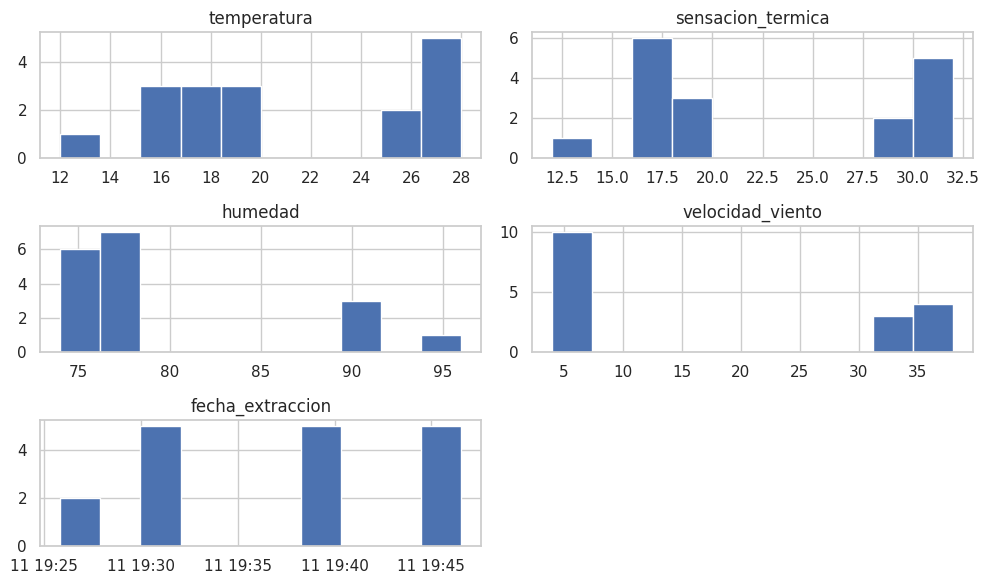

In [13]:
df.hist(figsize=(10,6))
plt.tight_layout()
plt.savefig("eda_distribuciones.png")
plt.show()

📁 Guardando en: data/graficas/eda_matriz_correlación.png


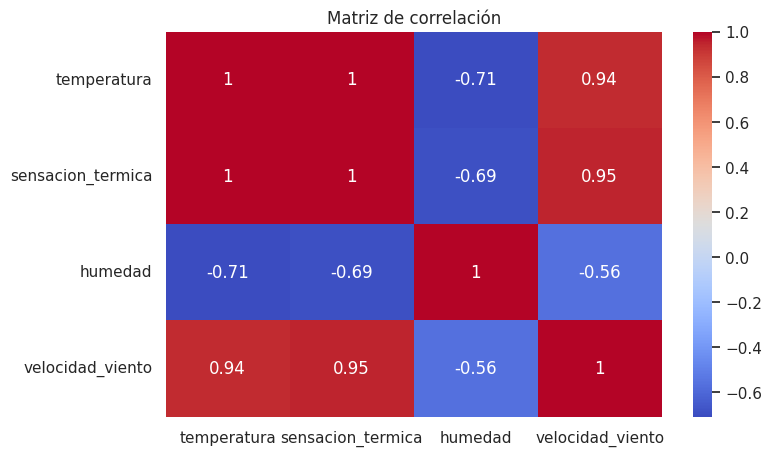

In [17]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.savefig("eda_matriz_correlación.png")
plt.show()

📁 Guardando en: data/graficas/eda_boxplots_ciudad.png


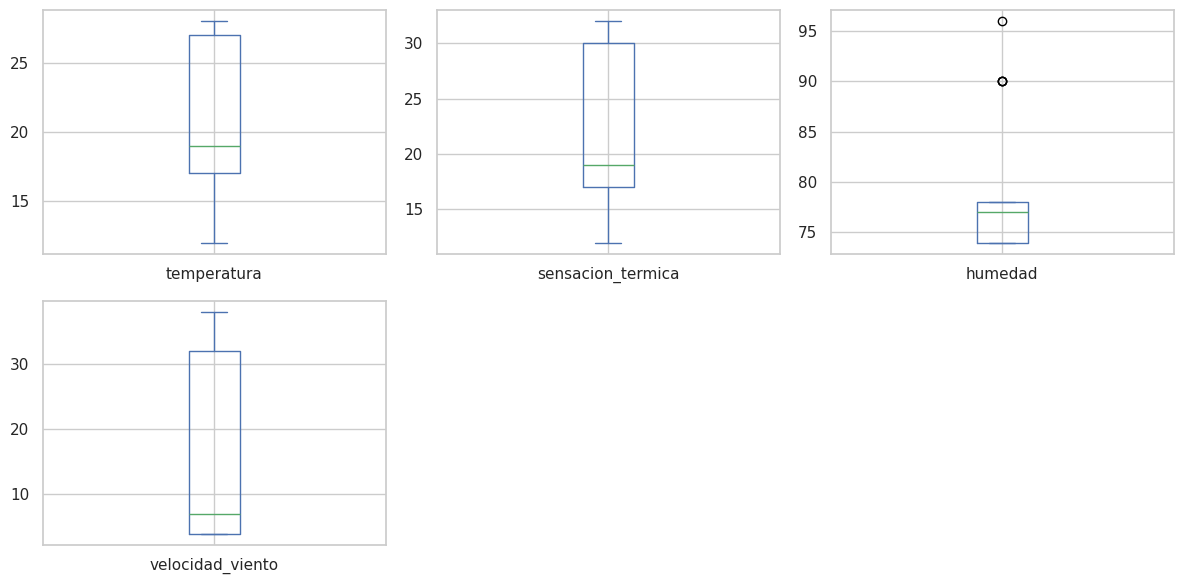

In [16]:
df.plot(kind='box', subplots=True, layout=(2,3), figsize=(12,6))
plt.tight_layout()
plt.savefig("eda_boxplots_ciudad.png")
plt.show()

📁 Guardando en: data/graficas/eda_scatter.png


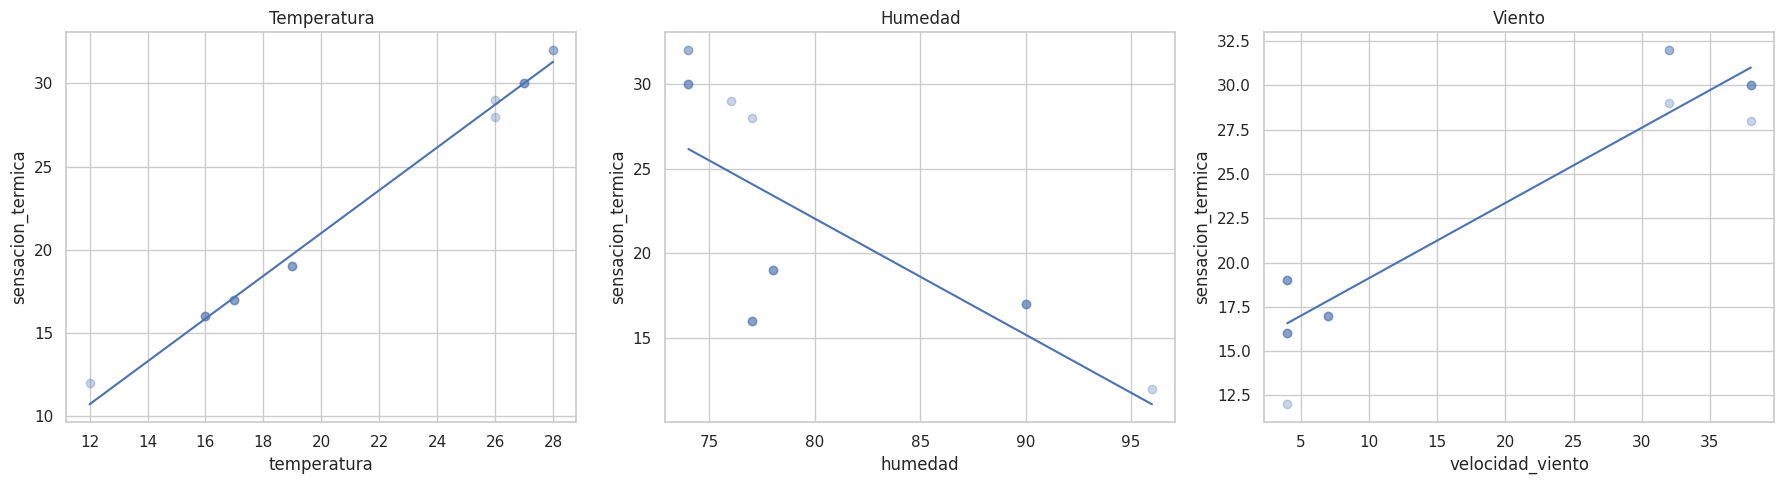

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pares = [
    ('temperatura', 'Temperatura'),
    ('humedad', 'Humedad'),
    ('velocidad_viento', 'Viento'),
]

for ax, (feature, name) in zip(axes, pares):
    ax.scatter(df[feature], df['sensacion_termica'], alpha=0.3)
    
    z = np.polyfit(df[feature], df['sensacion_termica'], 1)
    p = np.poly1d(z)
    
    xp = np.linspace(df[feature].min(), df[feature].max(), 100)
    ax.plot(xp, p(xp))
    
    ax.set_title(name)
    ax.set_xlabel(feature)
    ax.set_ylabel('sensacion_termica')

plt.tight_layout()
plt.savefig("eda_scatter.png")
plt.show()

In [19]:
X = df[['temperatura']].values
y = df['sensacion_termica'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (13, 1)
Test: (4, 1)


In [20]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Intercepto:", modelo.intercept_)
print("Coeficiente:", modelo.coef_[0])

Intercepto: -4.960735360871535
Coeficiente: 1.3007262823422603


📁 Guardando en: data/graficas/regresion_simple.png


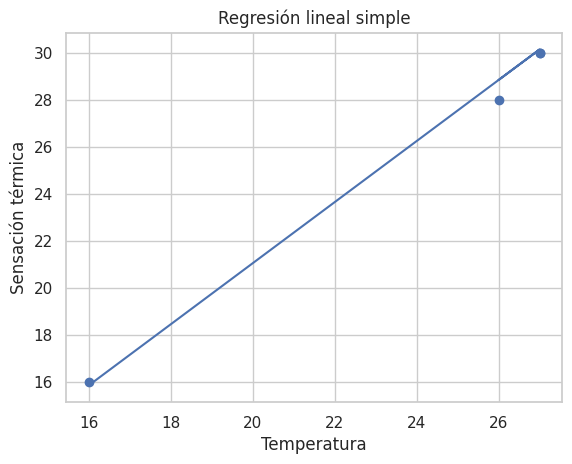

In [23]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Temperatura")
plt.ylabel("Sensación térmica")
plt.title("Regresión lineal simple")
plt.savefig("regresion_simple.png")
plt.show()

In [25]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2:", r2)
print("MSE:", mse)

R2: 0.9940504760688784
MSE: 0.20228381365813503


In [26]:
# OLS con statsmodels
X_ols = sm.add_constant(df['temperatura'])
modelo_ols = sm.OLS(df['sensacion_termica'], X_ols).fit()

print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:      sensacion_termica   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     2381.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           6.05e-18
Time:                        19:39:01   Log-Likelihood:                -13.578
No. Observations:                  17   AIC:                             31.16
Df Residuals:                      15   BIC:                             32.82
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -4.7122      0.571     -8.259      

/home/desarrollo/etl-weatherstack/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


📁 Guardando en: data/graficas/normalidad_simple_h.png


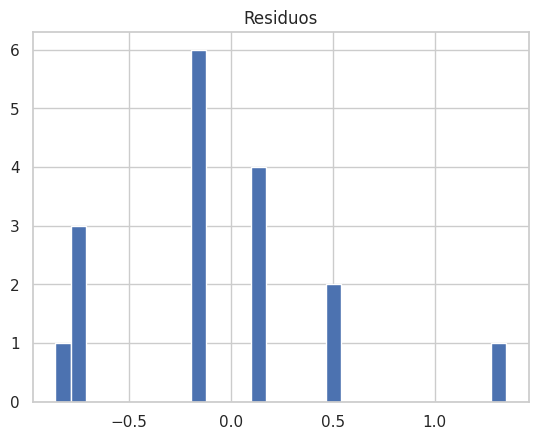

📁 Guardando en: data/graficas/normalidad_simple.png


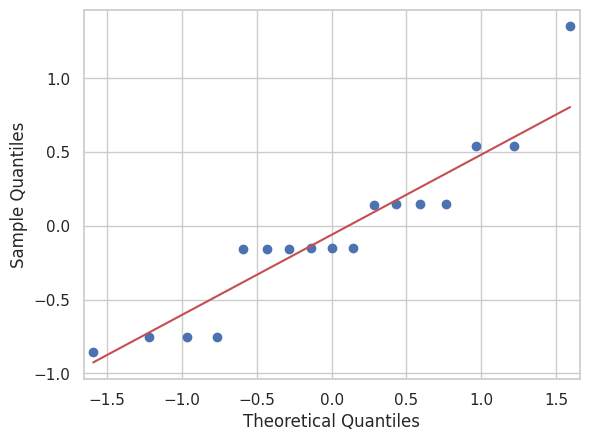

In [28]:
# Residuos
y_pred_all = modelo.predict(df[['temperatura']])
residuos = df['sensacion_termica'] - y_pred_all

# Histograma
plt.hist(residuos, bins=30)
plt.title("Residuos")
plt.savefig("normalidad_simple_h.png")
plt.show()

# Q-Q plot
sm.qqplot(residuos, line='s')
plt.savefig("normalidad_simple.png")
plt.show()

📁 Guardando en: data/graficas/residuos_vs_prediccion.png


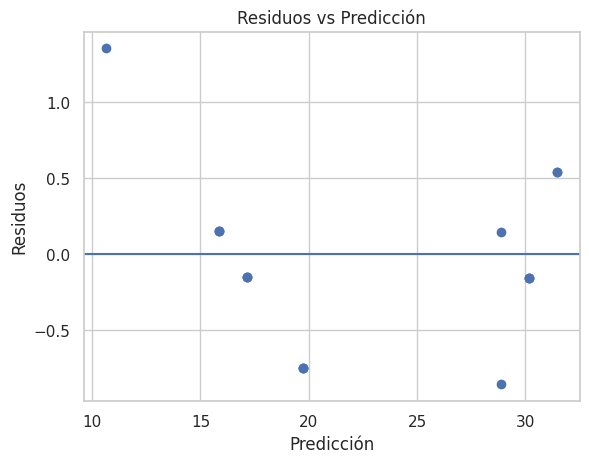

p-value: 0.2185798098741874


In [30]:
plt.scatter(y_pred_all, residuos)
plt.axhline(0)
plt.xlabel("Predicción")
plt.ylabel("Residuos")
plt.title("Residuos vs Predicción")
plt.savefig("residuos_vs_prediccion.png")
plt.show()

# Breusch-Pagan
test = het_breuschpagan(residuos, X_ols)
print("p-value:", test[1])

In [31]:
X_multi = df[['temperatura', 'humedad', 'velocidad_viento']]
y = df['sensacion_termica']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print("Intercepto:", modelo_multi.intercept_)
print("Coeficientes:", modelo_multi.coef_)

Intercepto: -2.2352254501829556
Coeficientes: [1.1002194  0.00178588 0.08392136]


📁 Guardando en: data/graficas/coeficientes_multi.png


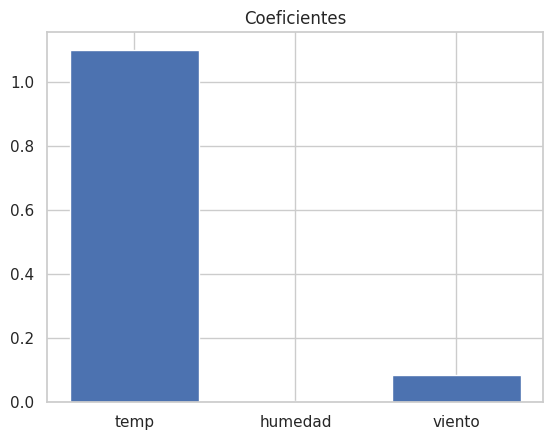

In [32]:
plt.bar(['temp', 'humedad', 'viento'], modelo_multi.coef_)
plt.title("Coeficientes")
plt.savefig("coeficientes_multi.png")
plt.show()

In [33]:
r2_m = r2_score(y_test_m, y_pred_multi)
mse_m = mean_squared_error(y_test_m, y_pred_multi)

print("R2:", r2_m)
print("MSE:", mse_m)

R2: 0.9694187672366494
MSE: 1.039761913953921


In [34]:
X_ols_m = sm.add_constant(X_multi)
modelo_ols_m = sm.OLS(y, X_ols_m).fit()

print(modelo_ols_m.summary())

                            OLS Regression Results                            
Dep. Variable:      sensacion_termica   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     849.1
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           3.70e-15
Time:                        19:42:21   Log-Likelihood:                -11.799
No. Observations:                  17   AIC:                             31.60
Df Residuals:                      13   BIC:                             34.93
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -4.3292      3.713  

In [35]:
X_vif = X_multi.copy()

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

           Variable        VIF
0       temperatura  70.683569
1           humedad  32.608464
2  velocidad_viento  13.881324


📁 Guardando en: data/graficas/diagnosticos_multi.png


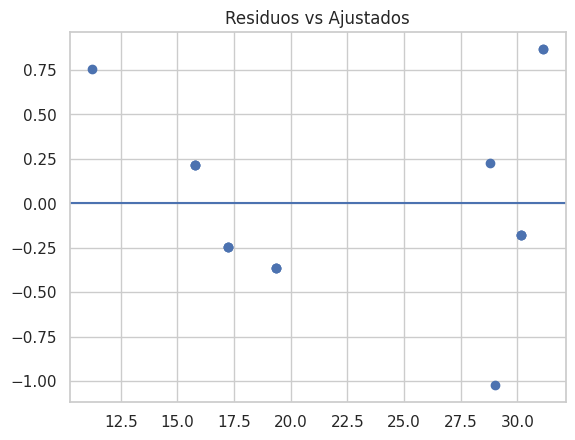

In [36]:
residuos_m = modelo_ols_m.resid
ajustados_m = modelo_ols_m.fittedvalues

plt.scatter(ajustados_m, residuos_m)
plt.axhline(0)
plt.title("Residuos vs Ajustados")
plt.savefig("diagnosticos_multi.png")
plt.show()

In [37]:
comparacion = pd.DataFrame({
    'Modelo': ['Simple', 'Multiple'],
    'R2': [r2, r2_m],
    'MSE': [mse, mse_m]
})

print(comparacion)

     Modelo        R2       MSE
0    Simple  0.994050  0.202284
1  Multiple  0.969419  1.039762


📁 Guardando en: data/graficas/predicciones_vs_reales.png


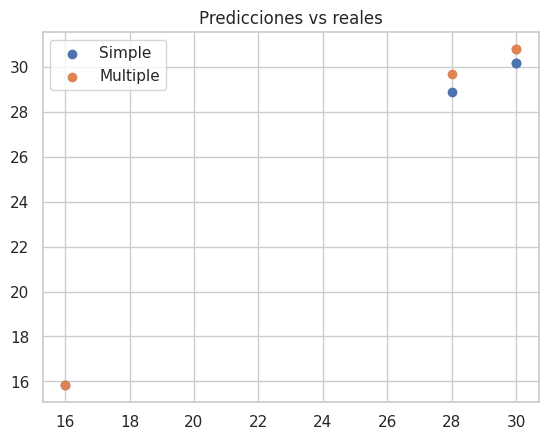

In [38]:
plt.scatter(y_test, y_pred, label="Simple")
plt.scatter(y_test_m, y_pred_multi, label="Multiple")

plt.legend()
plt.title("Predicciones vs reales")
plt.savefig("predicciones_vs_reales.png")
plt.show()